# ML-Driven Portfolio Optimization — Exploratory Data Analysis

This notebook explores historical price data for 5 major stocks (AAPL, MSFT, GOOGL, AMZN, TSLA)
from 2019-2025, calculates risk/return statistics, and applies Markowitz Modern Portfolio Theory
to identify optimal portfolio allocations.

**Sections:**
1. Data loading and inspection
2. Return distribution analysis
3. Volatility and correlation analysis
4. Markowitz portfolio optimization (Efficient Frontier)

In [44]:
import numpy as np

# How many random portfolios to simulate
num_portfolios = 10000
num_assets = len(expected_returns)

# Storage for results
results = np.zeros((3, num_portfolios))  # rows: return, volatility, Sharpe ratio
weights_record = []

np.random.seed(42)  # makes results reproducible - same random numbers every run

for i in range(num_portfolios):
    # Generate random weights that sum to 1 (100%)
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = portfolio_return(weights, expected_returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = port_return / port_volatility  # Sharpe ratio (simplified, no risk-free rate)

print("Simulation complete.")
print(f"Ran {num_portfolios} random portfolios.")

Simulation complete.
Ran 10000 random portfolios.


## 1. Load the Data
Loading the OHLCV price data we fetched via `yfinance` and saved to `data/raw_prices.csv`.

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data we saved earlier
df = pd.read_csv('../data/raw_prices.csv', header=[0, 1], index_col=0, parse_dates=True)
df.head()

Price           Close                                                   High  \
Ticker           AAPL       AMZN      GOOGL       MSFT       TSLA       AAPL   
Date                                                                           
2019-01-02  37.469212  76.956497  52.270512  94.193153  20.674667  37.689872   
2019-01-03  33.737003  75.014000  50.822838  90.727966  20.024000  34.574556   
2019-01-04  35.177200  78.769501  53.429722  94.947639  21.179333  35.246010   
2019-01-07  35.098904  81.475502  53.323170  95.068726  22.330667  35.312446   
2019-01-08  35.767994  82.829002  53.791523  95.758057  22.356667  36.021871   

Price                                                   ...       Open  \
Ticker           AMZN      GOOGL       MSFT       TSLA  ...       AAPL   
Date                                                    ...              
2019-01-02  77.667999  52.573327  94.779995  21.008667  ...  36.750293   
2019-01-03  76.900002  52.844413  93.326848  20.626667  ...  34.161710   
2019-01-04  79.699997  53.525374  95.487910  21.200001  ...  34.292196   
2019-01-07  81.727997  53.659187  96.195838  22.449333  ...  35.281600   
2019-01-08  83.830498  54.187014  96.847908  22.934000  ...  35.485646   

Price                                                      Volume             \
Ticker           AMZN      GOOGL       MSFT       TSLA       AAPL       AMZN   
Date                                                                           
2019-01-02  73.260002  50.908587  92.730701  20.406668  148158800  159662000   
2019-01-03  76.000504  52.071765  93.243010  20.466667  365248800  139512000   
2019-01-04  76.500000  51.669826  92.889029  20.400000  234428400  183652000   
2019-01-07  80.115501  53.573449  94.677498  21.448000  219111200  159864000   
2019-01-08  83.234497  53.822744  95.981614  22.797333  164101200  177628000   

Price                                      
Ticker         GOOGL      MSFT       TSLA  
Date                                       
2019-01-02  31868000  35329300  174879000  
2019-01-03  41960000  42579100  104478000  
2019-01-04  46022000  44060600  110911500  
2019-01-07  47446000  35656100  113268000  
2019-01-08  35414000  31514400  105127500  

[5 rows x 25 columns]

## 2. Calculate Daily Returns
Converting raw prices into daily percentage returns — the standard unit for portfolio analysis,
since it puts all stocks on a comparable scale regardless of price.

In [46]:
# Check the shape and date range of our data
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (1510, 25)
Date range: 2019-01-02 00:00:00 to 2024-12-31 00:00:00

Missing values:
Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        TSLA      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        TSLA      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        TSLA      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        TSLA      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        TSLA      0
dtype: int64


## 3. Return Distributions
Checking whether daily returns approximate a normal distribution — an assumption underlying
Markowitz optimization. Real stock returns typically show "fatter tails" than a perfect bell curve.

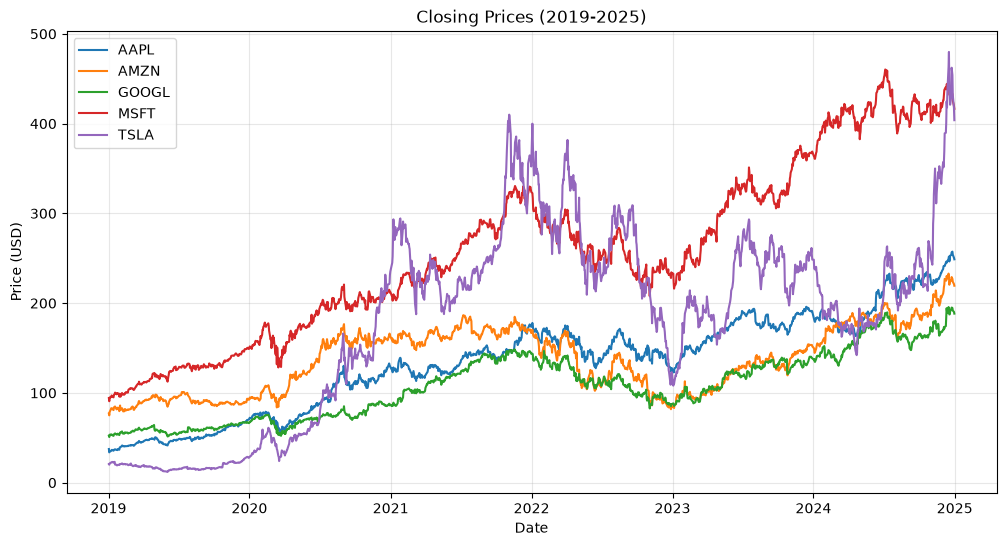

In [47]:
# Extract just the closing prices for plotting
close_prices = df['Close']

plt.figure(figsize=(12, 6))
for ticker in close_prices.columns:
    plt.plot(close_prices.index, close_prices[ticker], label=ticker)

plt.title('Closing Prices (2019-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Calculate daily percentage returns from closing prices
returns = close_prices.pct_change().dropna()

print(f"Shape: {returns.shape}")
returns.head()

Shape: (1509, 5)


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2019-01-03,-0.099607,-0.025241,-0.027696,-0.036788,-0.031472
2019-01-04,0.042689,0.050064,0.051294,0.046509,0.057697
2019-01-07,-0.002226,0.034353,-0.001994,0.001275,0.054361
2019-01-08,0.019063,0.016612,0.008783,0.007251,0.001164
2019-01-09,0.016982,0.001714,-0.003428,0.014299,0.009483


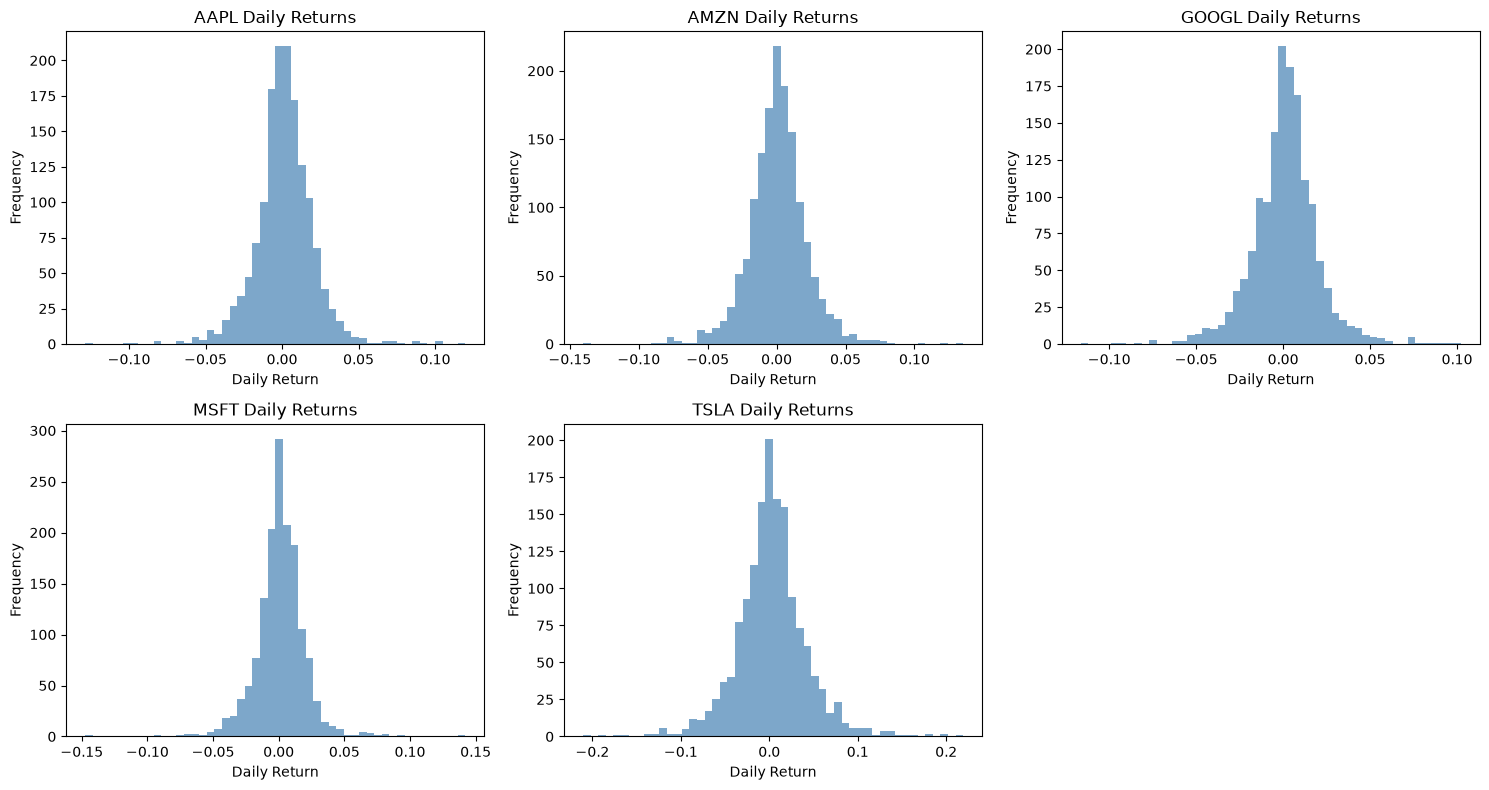

In [49]:
# Visualize the distribution of daily returns for each stock
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ticker in enumerate(returns.columns):
    axes[i].hist(returns[ticker], bins=50, alpha=0.7, color='steelblue')
    axes[i].set_title(f'{ticker} Daily Returns')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')

# Remove the empty 6th subplot (we only have 5 stocks)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 4. Volatility & Correlation
Calculating annualized volatility (risk) per stock and the correlation matrix between stocks —
the two statistical inputs Markowitz optimization requires.

In [50]:
# Daily volatility (standard deviation of daily returns)
daily_volatility = returns.std()

# Annualized volatility — multiply by sqrt(252), the ~number of trading days per year
# This converts a "daily" number into a more intuitive "yearly" number, standard practice in finance
annualized_volatility = daily_volatility * (252 ** 0.5)

print("Daily Volatility:")
print(daily_volatility)
print("\nAnnualized Volatility:")
print(annualized_volatility)

Daily Volatility:
Ticker
AAPL     0.019427
AMZN     0.021500
GOOGL    0.019658
MSFT     0.018266
TSLA     0.040618
dtype: float64

Annualized Volatility:
Ticker
AAPL     0.308397
AMZN     0.341296
GOOGL    0.312056
MSFT     0.289971
TSLA     0.644796
dtype: float64


In [51]:
# Correlation matrix: shows how each stock's returns relate to every other stock's
correlation_matrix = returns.corr()
correlation_matrix

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Ticker,,,,,
AAPL,1.000000,0.590568,0.638709,0.734542,0.465934
AMZN,0.590568,1.000000,0.644628,0.681954,0.420909
GOOGL,0.638709,0.644628,1.000000,0.736548,0.385025
MSFT,0.734542,0.681954,0.736548,1.000000,0.432224
TSLA,0.465934,0.420909,0.385025,0.432224,1.000000


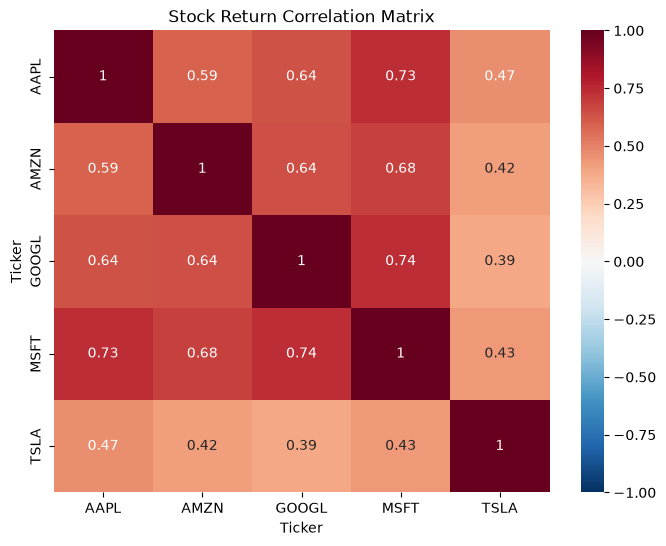

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Stock Return Correlation Matrix')
plt.show()

## 5. Markowitz Optimization — Efficient Frontier
Simulating 10,000 random portfolio weight combinations to visualize the risk/return tradeoff
and identify the Max Sharpe Ratio and Minimum Volatility portfolios.

In [53]:
# Expected annual return for each stock (mean daily return, annualized)
expected_returns = returns.mean() * 252

# Covariance matrix — this captures BOTH volatility AND correlation in one structure
# (Markowitz's formulas use covariance, not correlation, directly)
cov_matrix = returns.cov() * 252

print("Expected Annual Returns:")
print(expected_returns)
print("\nCovariance Matrix:")
print(cov_matrix)

Expected Annual Returns:
Ticker
AAPL     0.363900
AMZN     0.233196
GOOGL    0.262819
MSFT     0.290452
TSLA     0.703875
dtype: float64

Covariance Matrix:
Ticker      AAPL      AMZN     GOOGL      MSFT      TSLA
Ticker                                                  
AAPL    0.095109  0.062160  0.061467  0.065687  0.092652
AMZN    0.062160  0.116483  0.068655  0.067490  0.092628
GOOGL   0.061467  0.068655  0.097379  0.066648  0.077472
MSFT    0.065687  0.067490  0.066648  0.084083  0.080814
TSLA    0.092652  0.092628  0.077472  0.080814  0.415762


In [54]:
import numpy as np

def portfolio_return(weights, expected_returns):
    """Calculate expected return of a portfolio given weights."""
    return np.dot(weights, expected_returns)

def portfolio_volatility(weights, cov_matrix):
    """Calculate expected risk (volatility) of a portfolio given weights."""
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    return np.sqrt(variance)

equal_weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

test_return = portfolio_return(equal_weights, expected_returns)
test_volatility = portfolio_volatility(equal_weights, cov_matrix)

print(f"Equal-weighted portfolio:")
print(f"Expected Return: {test_return:.2%}")
print(f"Expected Volatility: {test_volatility:.2%}")

Equal-weighted portfolio:
Expected Return: 37.08%
Expected Volatility: 30.20%


In [55]:
import numpy as np

# How many random portfolios to simulate
num_portfolios = 10000
num_assets = len(expected_returns)

# Storage for results
results = np.zeros((3, num_portfolios))  # rows: return, volatility, Sharpe ratio
weights_record = []

np.random.seed(42)  # makes results reproducible - same random numbers every run

for i in range(num_portfolios):
    # Generate random weights that sum to 1 (100%)
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = portfolio_return(weights, expected_returns)
    port_volatility = portfolio_volatility(weights, cov_matrix)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = port_return / port_volatility  # Sharpe ratio (simplified, no risk-free rate)

print("Simulation complete.")
print(f"Ran {num_portfolios} random portfolios.")

Simulation complete.
Ran 10000 random portfolios.


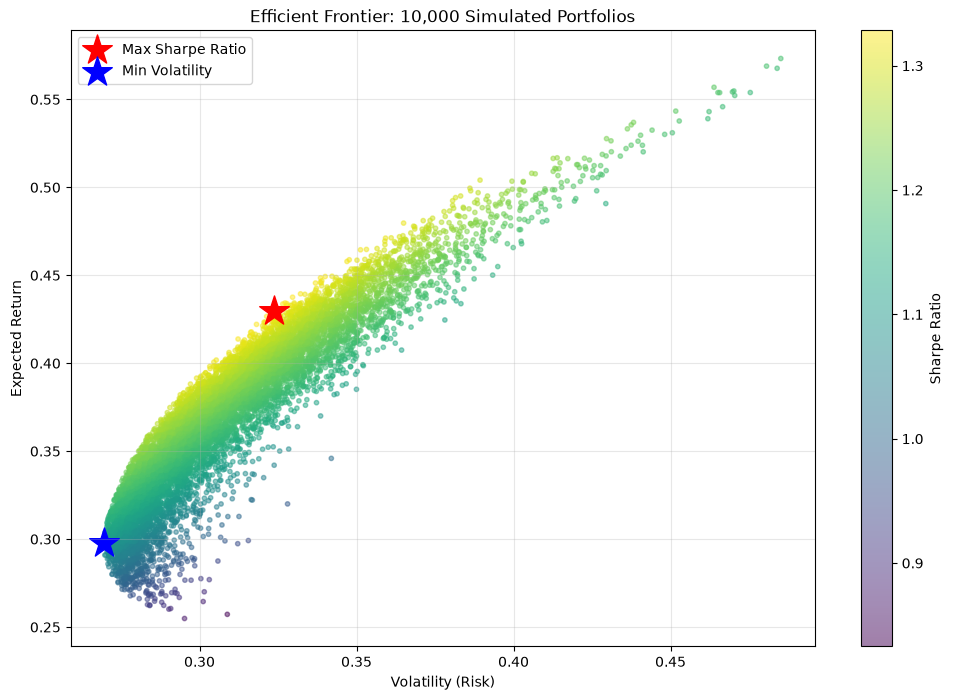

Max Sharpe Ratio Portfolio:
  Return: 42.99%, Volatility: 32.37%
  AAPL: 60.45%
  AMZN: 2.63%
  GOOGL: 1.39%
  MSFT: 12.06%
  TSLA: 23.46%

Min Volatility Portfolio:
  Return: 29.79%, Volatility: 26.97%
  AAPL: 27.30%
  AMZN: 12.35%
  GOOGL: 25.97%
  MSFT: 33.97%
  TSLA: 0.40%


In [56]:
# Find the portfolio with the highest Sharpe ratio (best risk-adjusted return)
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

# Find the portfolio with the lowest volatility (safest option)
min_vol_idx = np.argmin(results[1])
min_vol_return = results[0, min_vol_idx]
min_vol_volatility = results[1, min_vol_idx]
min_vol_weights = weights_record[min_vol_idx]

# Plot all 10,000 simulated portfolios
plt.figure(figsize=(12, 8))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(label='Sharpe Ratio')

# Highlight the best portfolios
plt.scatter(max_sharpe_volatility, max_sharpe_return, c='red', marker='*', s=500, label='Max Sharpe Ratio')
plt.scatter(min_vol_volatility, min_vol_return, c='blue', marker='*', s=500, label='Min Volatility')

plt.title('Efficient Frontier: 10,000 Simulated Portfolios')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the details of the two standout portfolios
print("Max Sharpe Ratio Portfolio:")
print(f"  Return: {max_sharpe_return:.2%}, Volatility: {max_sharpe_volatility:.2%}")
for ticker, weight in zip(expected_returns.index, max_sharpe_weights):
    print(f"  {ticker}: {weight:.2%}")

print("\nMin Volatility Portfolio:")
print(f"  Return: {min_vol_return:.2%}, Volatility: {min_vol_volatility:.2%}")
for ticker, weight in zip(expected_returns.index, min_vol_weights):
    print(f"  {ticker}: {weight:.2%}")